# RFUAV Open-Set RF Fingerprinting — Complete Pipeline

RNN → DenseNet-121 → Swin Transformer → GNN → FreqMoE-OSR (Proposed) → Comparison → Restricted-Airspace Simulator

In [ ]:
!pip install huggingface_hub -q

In [ ]:
!pip install google-api-python-client google-auth -q

In [ ]:
import json
from kaggle_secrets import UserSecretsClient
from google.oauth2 import service_account
from googleapiclient.discovery import build

user_secrets = UserSecretsClient()
creds_json = user_secrets.get_secret("GDRIVE_CREDS")
creds_dict = json.loads(creds_json)

credentials = service_account.Credentials.from_service_account_info(
    creds_dict, scopes=["https://www.googleapis.com/auth/drive.readonly"]
)
drive_service = build("drive", "v3", credentials=credentials)
print("Authenticated successfully!")

In [ ]:
import urllib.request
try:
    urllib.request.urlopen("https://huggingface.co", timeout=5)
    print("Internet is WORKING ✅")
except Exception as e:
    print("Internet is OFF ❌:", e)

In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:  # only show folders, limit depth to avoid huge output
        for d in dirs[:10]:
            pass
    # stop going deeper than 3 levels to avoid flooding output
    if level >= 3:
        dirs[:] = []

In [ ]:
import os

correct_path = "/kaggle/input/datasets/varshinirajasekaran/rfuav-research"
print("Contents:")
print(os.listdir(correct_path))

In [ ]:
import os

base_path = "/kaggle/input/datasets/varshinirajasekaran/rfuav-research/rfuav_images"
print("Contents of rfuav_images:")
print(os.listdir(base_path))

In [ ]:
import os

base_path = "/kaggle/input/datasets/varshinirajasekaran/rfuav-research/rfuav_images/ImageSet-AllDrones-MatlabPipeline"
print("Contents:")
print(os.listdir(base_path))

In [ ]:
import os

base_path = "/kaggle/input/datasets/varshinirajasekaran/rfuav-research/rfuav_images/ImageSet-AllDrones-MatlabPipeline"

train_classes = os.listdir(f"{base_path}/train")
valid_classes = os.listdir(f"{base_path}/valid")

print(f"Train classes: {len(train_classes)}")
print(train_classes)
print()
print(f"Valid classes: {len(valid_classes)}")
print(valid_classes)

In [ ]:
all_classes = train_classes  # 37 classes, already verified

# 12 classes selected as UNKNOWN (held-out, open-set test)
unknown_classes = [
    'DJI MINI4 PRO', 'SIYI MK32', 'FRSKY-X20R', 'FUTABA-T10J',
    'WFLY WFT09SII', 'FLYSKY EL 18', 'YunZhuo-H30', 'Radiolink AT9S Pro',
    'RadioMaster TX16S', 'JR PROPO XG7', 'JUMPER-T14', 'SKYDROID-H12'
]

# Remaining 25 classes = KNOWN (used for training + validation)
known_classes = [c for c in all_classes if c not in unknown_classes]

print(f"Known classes ({len(known_classes)}):")
print(known_classes)
print()
print(f"Unknown classes ({len(unknown_classes)}):")
print(unknown_classes)

In [ ]:
import os

base_path = "/kaggle/input/datasets/varshinirajasekaran/rfuav-research/rfuav_images/ImageSet-AllDrones-MatlabPipeline"

def collect_filepaths(split, classes):
    """Collect all image file paths for given classes in train/valid split"""
    filepaths = []
    labels = []
    for cls in classes:
        class_dir = os.path.join(base_path, split, cls)
        if os.path.exists(class_dir):
            for fname in os.listdir(class_dir):
                if fname.lower().endswith('.jpg'):
                    filepaths.append(os.path.join(class_dir, fname))
                    labels.append(cls)
    return filepaths, labels

# KNOWN classes -> training data (from 'train' split)
known_train_paths, known_train_labels = collect_filepaths('train', known_classes)

# KNOWN classes -> validation data (from 'valid' split)
known_valid_paths, known_valid_labels = collect_filepaths('valid', known_classes)

# UNKNOWN classes -> test data (both train + valid combined, since model never sees these)
unknown_train_paths, unknown_train_labels = collect_filepaths('train', unknown_classes)
unknown_valid_paths, unknown_valid_labels = collect_filepaths('valid', unknown_classes)

unknown_test_paths = unknown_train_paths + unknown_valid_paths
unknown_test_labels = unknown_train_labels + unknown_valid_labels

print(f"Known train images: {len(known_train_paths)}")
print(f"Known valid images: {len(known_valid_paths)}")
print(f"Unknown test images: {len(unknown_test_paths)}")
print(f"Total: {len(known_train_paths) + len(known_valid_paths) + len(unknown_test_paths)}")

In [ ]:
!pip install torch torchvision -q

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

# Step 1: Create label encoding (class name -> integer index)
class_to_idx = {cls: idx for idx, cls in enumerate(sorted(known_classes))}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

print("Class to index mapping:")
print(class_to_idx)

In [ ]:
# Step 2: Custom Dataset class
class RFUAVDataset(Dataset):
    def __init__(self, filepaths, labels, class_to_idx, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        label_name = self.labels[idx]
        label = self.class_to_idx[label_name]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
# Step 3: Define preprocessing transforms
# Standard spectrogram preprocessing: resize + normalize (ImageNet stats, since backbones are pretrained)

IMG_SIZE = 224  # standard for DenseNet/Swin; adjust per model later if needed

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),   # mild augmentation; spectrograms are time-frequency, flip carefully
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
# Step 4: Create Dataset instances
train_dataset = RFUAVDataset(known_train_paths, known_train_labels, class_to_idx, transform=train_transform)
valid_dataset = RFUAVDataset(known_valid_paths, known_valid_labels, class_to_idx, transform=eval_transform)

# For unknown/test set, we don't map to class_to_idx (these classes aren't in it)
# We'll handle this separately for open-set evaluation
class RFUAVUnknownDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels  # kept as string names for reference, not used in loss
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]  # return class name string, not index

unknown_test_dataset = RFUAVUnknownDataset(unknown_test_paths, unknown_test_labels, transform=eval_transform)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Valid dataset size: {len(valid_dataset)}")
print(f"Unknown test dataset size: {len(unknown_test_dataset)}")

In [ ]:
# Step 5: Create DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
unknown_test_loader = DataLoader(unknown_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("DataLoaders created successfully!")

In [ ]:
# Step 6: Quick sanity check - fetch one batch and verify shapes
images, labels = next(iter(train_loader))
print(f"Batch image shape: {images.shape}")   # expected: [32, 3, 224, 224]
print(f"Batch labels shape: {labels.shape}")  # expected: [32]
print(f"Sample labels: {labels[:5].tolist()}")
print(f"Corresponding class names: {[idx_to_class[l.item()] for l in labels[:5]]}")

In [ ]:
# ============================================================
# REPRODUCIBLE EXPERIMENT + RESULT SAVING
# ============================================================
import os, json, random, copy
import numpy as np
import pandas as pd
import torch

SEED = 42
RESULTS_DIR = "/kaggle/working/results"
CHECKPOINTS_DIR = "/kaggle/working/checkpoints"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

os.environ["PYTHONHASHSEED"] = str(SEED)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def get_dataloader_generator(seed=SEED):
    g = torch.Generator()
    g.manual_seed(seed)
    return g

def save_model_result(model_name, metrics_dict):
    safe_name = model_name.replace(" ", "_").replace("-", "_")

    save_data = {}
    for k, v in metrics_dict.items():
        if k == "confusion_matrix":
            save_data[k] = v.tolist() if hasattr(v, "tolist") else v
        elif isinstance(v, (np.floating, np.integer)):
            save_data[k] = float(v)
        else:
            save_data[k] = v

    # Individual JSON
    json_path = os.path.join(RESULTS_DIR, f"{safe_name}_metrics.json")
    with open(json_path, "w") as f:
        json.dump(save_data, f, indent=4)

    # Individual confusion matrix
    if "confusion_matrix" in metrics_dict:
        cm = np.asarray(metrics_dict["confusion_matrix"])
        pd.DataFrame(cm).to_csv(
            os.path.join(RESULTS_DIR, f"{safe_name}_confusion_matrix.csv"),
            index=False
        )

    # Individual one-row CSV
    summary = {
        k: v for k, v in save_data.items()
        if k != "confusion_matrix"
    }
    pd.DataFrame([summary]).to_csv(
        os.path.join(RESULTS_DIR, f"{safe_name}_metrics.csv"),
        index=False
    )

    # Human-readable text file
    txt_path = os.path.join(
        RESULTS_DIR,
        f"{safe_name}_metrics.txt"
    )
    with open(txt_path, "w") as f:
        f.write(f"Model: {model_name}\n")
        f.write("=" * 60 + "\n")
        for key, value in summary.items():
            if isinstance(value, (float, int, np.floating, np.integer)):
                f.write(f"{key}: {float(value):.6f}\n")
            else:
                f.write(f"{key}: {value}\n")

    print(f"Saved results for {model_name}")

set_seed(SEED)
print(f"Reproducibility enabled. SEED = {SEED}")


In [ ]:
# ============================================================
# RFUAV DATASET SPLIT — SAME DATA AS ORIGINAL NOTEBOOK
# ============================================================

base_path = "/kaggle/input/datasets/varshinirajasekaran/rfuav-research/rfuav_images/ImageSet-AllDrones-MatlabPipeline"

train_classes = sorted(os.listdir(f"{base_path}/train"))

# 12 classes held out as UNKNOWN
unknown_classes = [
    'DJI MINI4 PRO', 'SIYI MK32', 'FRSKY-X20R', 'FUTABA-T10J',
    'WFLY WFT09SII', 'FLYSKY EL 18', 'YunZhuo-H30', 'Radiolink AT9S Pro',
    'RadioMaster TX16S', 'JR PROPO XG7', 'JUMPER-T14', 'SKYDROID-H12'
]

# Remaining 25 classes are KNOWN
known_classes = sorted([c for c in train_classes if c not in unknown_classes])

class_to_idx = {cls: idx for idx, cls in enumerate(known_classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

def collect_filepaths(split, classes):
    filepaths, labels = [], []

    for cls in sorted(classes):
        class_dir = os.path.join(base_path, split, cls)

        if os.path.exists(class_dir):
            for fname in sorted(os.listdir(class_dir)):
                if fname.lower().endswith(".jpg"):
                    filepaths.append(os.path.join(class_dir, fname))
                    labels.append(cls)

    return filepaths, labels

known_train_paths, known_train_labels = collect_filepaths("train", known_classes)
known_valid_paths, known_valid_labels = collect_filepaths("valid", known_classes)

unknown_train_paths, unknown_train_labels = collect_filepaths("train", unknown_classes)
unknown_valid_paths, unknown_valid_labels = collect_filepaths("valid", unknown_classes)

unknown_test_paths = unknown_train_paths + unknown_valid_paths
unknown_test_labels = unknown_train_labels + unknown_valid_labels

print(f"Known classes   : {len(known_classes)}")
print(f"Unknown classes : {len(unknown_classes)}")
print(f"Known train     : {len(known_train_paths)}")
print(f"Known validation: {len(known_valid_paths)}")
print(f"Unknown test    : {len(unknown_test_paths)}")


In [ ]:
# ============================================================
# IMPORTS + SHARED TRAINING / EVALUATION FUNCTIONS
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224

print(f"Using device: {device}")

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += x.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)

    return total_loss / total, correct / total


def full_evaluation(model, valid_loader, unknown_loader, device, forward_fn=None):
    """
    Closed-set:
        Accuracy
        Macro Precision / Recall / F1
        Weighted Precision / Recall / F1

    Open-set:
        AUROC using maximum softmax confidence.
    """
    if forward_fn is None:
        forward_fn = lambda m, x: m(x)

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in valid_loader:
            logits = forward_fn(model, x.to(device))

            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())

    all_preds = np.asarray(all_preds)
    all_labels = np.asarray(all_labels)

    accuracy = accuracy_score(all_labels, all_preds)

    macro_precision = precision_score(
        all_labels, all_preds, average="macro", zero_division=0
    )
    macro_recall = recall_score(
        all_labels, all_preds, average="macro", zero_division=0
    )
    macro_f1 = f1_score(
        all_labels, all_preds, average="macro", zero_division=0
    )

    weighted_precision = precision_score(
        all_labels, all_preds, average="weighted", zero_division=0
    )
    weighted_recall = recall_score(
        all_labels, all_preds, average="weighted", zero_division=0
    )
    weighted_f1 = f1_score(
        all_labels, all_preds, average="weighted", zero_division=0
    )

    cm = confusion_matrix(all_labels, all_preds)

    # Known confidence
    known_probs = []
    with torch.no_grad():
        for x, _ in valid_loader:
            logits = forward_fn(model, x.to(device))
            known_probs.extend(
                F.softmax(logits, dim=1).max(1)[0].cpu().numpy()
            )

    # Unknown confidence
    unknown_probs = []
    with torch.no_grad():
        for x, _ in unknown_loader:
            logits = forward_fn(model, x.to(device))
            unknown_probs.extend(
                F.softmax(logits, dim=1).max(1)[0].cpu().numpy()
            )

    y_true_binary = np.concatenate([
        np.ones(len(known_probs)),
        np.zeros(len(unknown_probs))
    ])

    confidence_scores = np.concatenate([
        known_probs,
        unknown_probs
    ])

    auroc = roc_auc_score(
        y_true_binary,
        confidence_scores
    )

    print("\n" + "=" * 70)
    print("MODEL METRICS")
    print("=" * 70)
    print(f"Accuracy           : {accuracy:.4f}")
    print(f"Macro Precision    : {macro_precision:.4f}")
    print(f"Macro Recall       : {macro_recall:.4f}")
    print(f"Macro F1-score     : {macro_f1:.4f}")
    print(f"Weighted Precision : {weighted_precision:.4f}")
    print(f"Weighted Recall    : {weighted_recall:.4f}")
    print(f"Weighted F1-score  : {weighted_f1:.4f}")
    print(f"Open-set AUROC     : {auroc:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            all_labels,
            all_preds,
            zero_division=0
        )
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "auroc": auroc,
        "confusion_matrix": cm
    }


def plot_confusion(cm, title):
    class_names = [
        idx_to_class[i]
        for i in range(len(known_classes))
    ]

    plt.figure(figsize=(14, 12))

    sns.heatmap(
        cm,
        annot=False,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


print("Shared utilities ready!")


In [ ]:
# ============================================================
# DETERMINISTIC DATALOADER HELPERS
# ============================================================

def make_train_loader(dataset, batch_size=32, num_workers=2, seed=SEED):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=get_dataloader_generator(seed)
    )

def make_eval_loader(dataset, batch_size=32, num_workers=2):
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

print("Deterministic DataLoader helpers ready!")


In [ ]:
def collect_filepaths(split, classes):
    filepaths, labels = [], []
    for cls in sorted(classes):  # sort class order
        class_dir = os.path.join(base_path, split, cls)
        if os.path.exists(class_dir):
            for fname in sorted(os.listdir(class_dir)):  # sort file order
                if fname.lower().endswith('.jpg'):
                    filepaths.append(os.path.join(class_dir, fname))
                    labels.append(cls)
    return filepaths, labels

# 1. RNN (Bidirectional LSTM) Baseline


In [ ]:
import os
import json
import numpy as np

RESULTS_DIR = "/kaggle/working/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

def save_model_result(model_name, metrics_dict):
    save_data = {}
    for k, v in metrics_dict.items():
        if k == 'confusion_matrix':
            save_data[k] = v.tolist()
        elif isinstance(v, (np.floating, np.integer)):
            save_data[k] = float(v)
        else:
            save_data[k] = v
    filepath = os.path.join(RESULTS_DIR, f"{model_name.replace(' ', '_')}.json")
    with open(filepath, 'w') as f:
        json.dump(save_data, f, indent=4)
    print(f"Saved permanently: {filepath}")

print("Save system ready!")

In [ ]:
import os

base_path = "/kaggle/input/datasets/varshinirajasekaran/rfuav-research/rfuav_images/ImageSet-AllDrones-MatlabPipeline"
train_classes = os.listdir(f"{base_path}/train")

all_classes = train_classes
unknown_classes = [
    'DJI MINI4 PRO', 'SIYI MK32', 'FRSKY-X20R', 'FUTABA-T10J',
    'WFLY WFT09SII', 'FLYSKY EL 18', 'YunZhuo-H30', 'Radiolink AT9S Pro',
    'RadioMaster TX16S', 'JR PROPO XG7', 'JUMPER-T14', 'SKYDROID-H12'
]
known_classes = [c for c in all_classes if c not in unknown_classes]

class_to_idx = {cls: idx for idx, cls in enumerate(sorted(known_classes))}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

def collect_filepaths(split, classes):
    filepaths, labels = [], []
    for cls in classes:
        class_dir = os.path.join(base_path, split, cls)
        if os.path.exists(class_dir):
            for fname in os.listdir(class_dir):
                if fname.lower().endswith('.jpg'):
                    filepaths.append(os.path.join(class_dir, fname))
                    labels.append(cls)
    return filepaths, labels

known_train_paths, known_train_labels = collect_filepaths('train', known_classes)
known_valid_paths, known_valid_labels = collect_filepaths('valid', known_classes)
unknown_train_paths, unknown_train_labels = collect_filepaths('train', unknown_classes)
unknown_valid_paths, unknown_valid_labels = collect_filepaths('valid', unknown_classes)
unknown_test_paths = unknown_train_paths + unknown_valid_paths
unknown_test_labels = unknown_train_labels + unknown_valid_labels

print(f"Known: {len(known_classes)}, Unknown: {len(unknown_classes)}")
print(f"Train: {len(known_train_paths)}, Valid: {len(known_valid_paths)}, Unknown test: {len(unknown_test_paths)}")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [ ]:
IMG_SIZE = 224

class RFUAVSequenceDataset(Dataset):
    def __init__(self, filepaths, labels, class_to_idx, img_size=224):
        self.filepaths = filepaths
        self.labels = labels
        self.class_to_idx = class_to_idx
        self.img_size = img_size

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        label = self.class_to_idx[self.labels[idx]]
        image = Image.open(img_path).convert('L')
        image = image.resize((self.img_size, self.img_size))
        image = np.array(image, dtype=np.float32) / 255.0
        sequence = torch.tensor(image.T, dtype=torch.float32)
        return sequence, torch.tensor(label, dtype=torch.long)

class RFUAVUnknownSequenceDataset(Dataset):
    def __init__(self, filepaths, labels, img_size=224):
        self.filepaths = filepaths
        self.labels = labels
        self.img_size = img_size

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        image = Image.open(img_path).convert('L')
        image = image.resize((self.img_size, self.img_size))
        image = np.array(image, dtype=np.float32) / 255.0
        sequence = torch.tensor(image.T, dtype=torch.float32)
        return sequence, self.labels[idx]

train_seq_dataset = RFUAVSequenceDataset(known_train_paths, known_train_labels, class_to_idx, IMG_SIZE)
valid_seq_dataset = RFUAVSequenceDataset(known_valid_paths, known_valid_labels, class_to_idx, IMG_SIZE)
unknown_seq_dataset = RFUAVUnknownSequenceDataset(unknown_test_paths, unknown_test_labels, IMG_SIZE)

BATCH_SIZE = 32
train_seq_loader = DataLoader(train_seq_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
valid_seq_loader = DataLoader(valid_seq_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
unknown_seq_loader = DataLoader(unknown_seq_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("DataLoaders ready!")

In [ ]:
class RNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, num_classes=25, bidirectional=True):
        super(RNNClassifier, self).__init__()
        self.rnn = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=bidirectional, dropout=0.3 if num_layers > 1 else 0)
        direction_factor = 2 if bidirectional else 1
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * direction_factor, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        rnn_out, _ = self.rnn(x)
        last_hidden = rnn_out[:, -1, :]
        return self.classifier(last_hidden)

model = RNNClassifier(input_dim=IMG_SIZE, hidden_dim=128, num_layers=2,
                       num_classes=len(known_classes), bidirectional=True).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for sequences, labels in loader:
        sequences, labels = sequences.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(sequences)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * sequences.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += sequences.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for sequences, labels in loader:
            sequences, labels = sequences.to(device), labels.to(device)
            outputs = model(sequences)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * sequences.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += sequences.size(0)
    return total_loss / total, correct / total

NUM_EPOCHS = 20
best_valid_acc = 0
best_model_state = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_seq_loader, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, valid_seq_loader, criterion, device)
    scheduler.step(valid_loss)
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        best_model_state = model.state_dict().copy()
    print(f"Epoch {epoch}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_acc:.4f}")

print(f"\nBest Validation Accuracy: {best_valid_acc:.4f}")

In [ ]:
model.load_state_dict(best_model_state)
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for sequences, labels in valid_seq_loader:
        sequences = sequences.to(device)
        outputs = model(sequences)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = accuracy_score(all_labels, all_preds)
macro_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
weighted_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

cm = confusion_matrix(all_labels, all_preds)

known_probs, unknown_probs = [], []
with torch.no_grad():
    for sequences, labels in valid_seq_loader:
        sequences = sequences.to(device)
        outputs = F.softmax(model(sequences), dim=1)
        known_probs.extend(outputs.max(dim=1)[0].cpu().numpy())
    for sequences, labels in unknown_seq_loader:
        sequences = sequences.to(device)
        outputs = F.softmax(model(sequences), dim=1)
        unknown_probs.extend(outputs.max(dim=1)[0].cpu().numpy())

y_true_binary = np.concatenate([np.ones(len(known_probs)), np.zeros(len(unknown_probs))])
y_scores = np.concatenate([known_probs, unknown_probs])
auroc = roc_auc_score(y_true_binary, y_scores)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}, Macro Recall: {macro_recall:.4f}, Macro F1: {macro_f1:.4f}")
print(f"Weighted Precision: {weighted_precision:.4f}, Weighted Recall: {weighted_recall:.4f}, Weighted F1: {weighted_f1:.4f}")
print(f"Open-Set AUROC: {auroc:.4f}")

class_names = [idx_to_class[i] for i in range(len(known_classes))]
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - RNN Baseline')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

rnn_results = {
    'accuracy': accuracy,
    'macro_precision': macro_precision,
    'macro_recall': macro_recall,
    'macro_f1': macro_f1,
    'weighted_precision': weighted_precision,
    'weighted_recall': weighted_recall,
    'weighted_f1': weighted_f1,
    'auroc': auroc,
    'confusion_matrix': cm
}

# PERMANENT SAVE - connected to save system
save_model_result('RNN', rnn_results)

In [ ]:
import os
print(os.listdir("/kaggle/working/results"))

In [ ]:
print("accuracy" in dir())

In [ ]:
def save_model_result(model_name, metrics_dict):
    save_data = {}
    for k, v in metrics_dict.items():
        if k == 'confusion_matrix':
            save_data[k] = v.tolist() if hasattr(v, 'tolist') else v
        elif isinstance(v, (np.floating, np.integer)):
            save_data[k] = float(v)
        else:
            save_data[k] = v
    filepath = os.path.join(RESULTS_DIR, f"{model_name.replace(' ', '_')}.json")
    with open(filepath, 'w') as f:
        json.dump(save_data, f, indent=4)
    print(f"Saved permanently: {filepath}")

print("Save function updated!")

In [ ]:
save_model_result('RNN', {
    'accuracy': 0.4996,
    'macro_precision': 0.2809,
    'macro_recall': 0.3360,
    'macro_f1': 0.2773,
    'weighted_precision': 0.4315,
    'weighted_recall': 0.4996,
    'weighted_f1': 0.4352,
    'auroc': 0.6721,
    'confusion_matrix': [[0]]
})

# 2. DenseNet-121 (Transfer Learning)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [ ]:
print("known_train_paths" in dir())

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224

class RFUAVImageDataset(Dataset):
    def __init__(self, filepaths, labels, class_to_idx, transform=None):
        self.filepaths, self.labels, self.class_to_idx, self.transform = filepaths, labels, class_to_idx, transform
    def __len__(self): return len(self.filepaths)
    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, torch.tensor(self.class_to_idx[self.labels[idx]], dtype=torch.long)

class RFUAVUnknownImageDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths, self.labels, self.transform = filepaths, labels, transform
    def __len__(self): return len(self.filepaths)
    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, self.labels[idx]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

train_img_dataset = RFUAVImageDataset(known_train_paths, known_train_labels, class_to_idx, train_transform)
valid_img_dataset = RFUAVImageDataset(known_valid_paths, known_valid_labels, class_to_idx, eval_transform)
unknown_img_dataset = RFUAVUnknownImageDataset(unknown_test_paths, unknown_test_labels, eval_transform)

BATCH_SIZE = 32
train_img_loader = DataLoader(train_img_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
valid_img_loader = DataLoader(valid_img_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
unknown_img_loader = DataLoader(unknown_img_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print("DenseNet DataLoaders ready!")

In [ ]:
IMG_SIZE = 224

class RFUAVImageDataset(Dataset):
    def __init__(self, filepaths, labels, class_to_idx, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        label = self.class_to_idx[self.labels[idx]]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

class RFUAVUnknownImageDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_img_dataset = RFUAVImageDataset(known_train_paths, known_train_labels, class_to_idx, train_transform)
valid_img_dataset = RFUAVImageDataset(known_valid_paths, known_valid_labels, class_to_idx, eval_transform)
unknown_img_dataset = RFUAVUnknownImageDataset(unknown_test_paths, unknown_test_labels, eval_transform)

BATCH_SIZE = 32
train_img_loader = DataLoader(train_img_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
valid_img_loader = DataLoader(valid_img_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
unknown_img_loader = DataLoader(unknown_img_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Image DataLoaders ready!")

In [ ]:
class DenseNetClassifier(nn.Module):
    def __init__(self, num_classes=25, pretrained=True):
        super(DenseNetClassifier, self).__init__()
        self.backbone = models.densenet121(weights='IMAGENET1K_V1' if pretrained else None)
        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model = DenseNetClassifier(num_classes=len(known_classes), pretrained=True).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

In [ ]:
class DenseNetClassifier(nn.Module):
    def __init__(self, num_classes=25, pretrained=True):
        super().__init__()
        self.backbone = models.densenet121(weights='IMAGENET1K_V1' if pretrained else None)
        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Sequential(nn.Linear(in_features, 256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, num_classes))
    def forward(self, x): return self.backbone(x)

model = DenseNetClassifier(num_classes=len(known_classes), pretrained=True).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train(); total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward(); optimizer.step()
        total_loss += loss.item()*images.size(0); correct += (outputs.argmax(1)==labels).sum().item(); total += images.size(0)
    return total_loss/total, correct/total

def evaluate(model, loader, criterion, device):
    model.eval(); total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()*images.size(0); correct += (outputs.argmax(1)==labels).sum().item(); total += images.size(0)
    return total_loss/total, correct/total

NUM_EPOCHS = 15
best_valid_acc, best_model_state = 0, None
for epoch in range(1, NUM_EPOCHS+1):
    train_loss, train_acc = train_epoch(model, train_img_loader, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, valid_img_loader, criterion, device)
    scheduler.step(valid_loss)
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc; best_model_state = model.state_dict().copy()
    print(f"Epoch {epoch}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_acc:.4f}")
print(f"\nBest Validation Accuracy: {best_valid_acc:.4f}")

In [ ]:
model.load_state_dict(best_model_state); model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in valid_img_loader:
        outputs = model(images.to(device))
        all_preds.extend(outputs.argmax(1).cpu().numpy()); all_labels.extend(labels.numpy())
all_preds, all_labels = np.array(all_preds), np.array(all_labels)

accuracy = accuracy_score(all_labels, all_preds)
macro_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
weighted_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
cm = confusion_matrix(all_labels, all_preds)

known_probs, unknown_probs = [], []
with torch.no_grad():
    for images, labels in valid_img_loader:
        known_probs.extend(F.softmax(model(images.to(device)),1).max(1)[0].cpu().numpy())
    for images, labels in unknown_img_loader:
        unknown_probs.extend(F.softmax(model(images.to(device)),1).max(1)[0].cpu().numpy())
y_true_binary = np.concatenate([np.ones(len(known_probs)), np.zeros(len(unknown_probs))])
y_scores = np.concatenate([known_probs, unknown_probs])
auroc = roc_auc_score(y_true_binary, y_scores)

print(f"Accuracy: {accuracy:.4f}, Macro F1: {macro_f1:.4f}, Weighted F1: {weighted_f1:.4f}, AUROC: {auroc:.4f}")

class_names = [idx_to_class[i] for i in range(len(known_classes))]
plt.figure(figsize=(14,12)); sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - DenseNet-121'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=90); plt.yticks(rotation=0); plt.tight_layout(); plt.show()

save_model_result('DenseNet-121', {
    'accuracy': accuracy, 'macro_precision': macro_precision, 'macro_recall': macro_recall, 'macro_f1': macro_f1,
    'weighted_precision': weighted_precision, 'weighted_recall': weighted_recall, 'weighted_f1': weighted_f1,
    'auroc': auroc, 'confusion_matrix': cm
})

In [ ]:
import os, json
import numpy as np

RESULTS_DIR = "/kaggle/working/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

def save_model_result(model_name, metrics_dict):
    save_data = {}
    for k, v in metrics_dict.items():
        if k == 'confusion_matrix':
            save_data[k] = v.tolist()
        elif isinstance(v, (np.floating, np.integer)):
            save_data[k] = float(v)
        else:
            save_data[k] = v
    filepath = os.path.join(RESULTS_DIR, f"{model_name.replace(' ', '_')}.json")
    with open(filepath, 'w') as f:
        json.dump(save_data, f, indent=4)
    print(f"Saved permanently: {filepath}")

print("Save system ready!")

In [ ]:
save_model_result('DenseNet-121', {
    'accuracy': accuracy, 'macro_precision': macro_precision, 'macro_recall': macro_recall, 'macro_f1': macro_f1,
    'weighted_precision': weighted_precision, 'weighted_recall': weighted_recall, 'weighted_f1': weighted_f1,
    'auroc': auroc, 'confusion_matrix': cm
})

# 3. Swin Transformer (Transfer Learning) — reuses DenseNet's image DataLoaders

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [ ]:
IMG_SIZE = 224

class RFUAVImageDataset(Dataset):
    def __init__(self, filepaths, labels, class_to_idx, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        label = self.class_to_idx[self.labels[idx]]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

class RFUAVUnknownImageDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_img_dataset = RFUAVImageDataset(known_train_paths, known_train_labels, class_to_idx, train_transform)
valid_img_dataset = RFUAVImageDataset(known_valid_paths, known_valid_labels, class_to_idx, eval_transform)
unknown_img_dataset = RFUAVUnknownImageDataset(unknown_test_paths, unknown_test_labels, eval_transform)

BATCH_SIZE = 32
train_img_loader = DataLoader(train_img_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
valid_img_loader = DataLoader(valid_img_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
unknown_img_loader = DataLoader(unknown_img_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Image DataLoaders ready!")

In [ ]:
class SwinClassifier(nn.Module):
    def __init__(self, num_classes=25, pretrained=True):
        super().__init__()
        self.backbone = models.swin_t(weights='IMAGENET1K_V1' if pretrained else None)
        in_features = self.backbone.head.in_features
        self.backbone.head = nn.Sequential(nn.Linear(in_features, 256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, num_classes))
    def forward(self, x): return self.backbone(x)

model = SwinClassifier(num_classes=len(known_classes), pretrained=True).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

NUM_EPOCHS = 15
best_valid_acc, best_model_state = 0, None
for epoch in range(1, NUM_EPOCHS+1):
    train_loss, train_acc = train_epoch(model, train_img_loader, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate(model, valid_img_loader, criterion, device)
    scheduler.step(valid_loss)
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc; best_model_state = model.state_dict().copy()
    print(f"Epoch {epoch}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_acc:.4f}")
print(f"\nBest Validation Accuracy: {best_valid_acc:.4f}")

In [ ]:
model.load_state_dict(best_model_state); model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in valid_img_loader:
        outputs = model(images.to(device))
        all_preds.extend(outputs.argmax(1).cpu().numpy()); all_labels.extend(labels.numpy())
all_preds, all_labels = np.array(all_preds), np.array(all_labels)

accuracy = accuracy_score(all_labels, all_preds)
macro_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
weighted_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
cm = confusion_matrix(all_labels, all_preds)

known_probs, unknown_probs = [], []
with torch.no_grad():
    for images, labels in valid_img_loader:
        known_probs.extend(F.softmax(model(images.to(device)),1).max(1)[0].cpu().numpy())
    for images, labels in unknown_img_loader:
        unknown_probs.extend(F.softmax(model(images.to(device)),1).max(1)[0].cpu().numpy())
y_true_binary = np.concatenate([np.ones(len(known_probs)), np.zeros(len(unknown_probs))])
y_scores = np.concatenate([known_probs, unknown_probs])
auroc = roc_auc_score(y_true_binary, y_scores)

print(f"Accuracy: {accuracy:.4f}, Macro F1: {macro_f1:.4f}, Weighted F1: {weighted_f1:.4f}, AUROC: {auroc:.4f}")

class_names = [idx_to_class[i] for i in range(len(known_classes))]
plt.figure(figsize=(14,12)); sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Swin Transformer'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=90); plt.yticks(rotation=0); plt.tight_layout(); plt.show()

save_model_result('Swin_Transformer', {
    'accuracy': accuracy, 'macro_precision': macro_precision, 'macro_recall': macro_recall, 'macro_f1': macro_f1,
    'weighted_precision': weighted_precision, 'weighted_recall': weighted_recall, 'weighted_f1': weighted_f1,
    'auroc': auroc, 'confusion_matrix': cm
})

# 4. GNN (Simple GCN) Baseline

In [ ]:
!pip install torch_geometric -q

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv, global_mean_pool
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [ ]:
def image_to_graph(image_tensor, patch_size=16):
    C, H, W = image_tensor.shape
    n_patches_h = H // patch_size
    n_patches_w = W // patch_size
    num_nodes = n_patches_h * n_patches_w

    patches = image_tensor.unfold(1, patch_size, patch_size).unfold(2, patch_size, patch_size)
    patches = patches.contiguous().view(C, num_nodes, patch_size * patch_size)
    node_features = patches.permute(1, 0, 2).reshape(num_nodes, -1)

    edge_index = []
    for i in range(n_patches_h):
        for j in range(n_patches_w):
            idx = i * n_patches_w + j
            if j < n_patches_w - 1:
                edge_index.append([idx, idx + 1])
                edge_index.append([idx + 1, idx])
            if i < n_patches_h - 1:
                edge_index.append([idx, idx + n_patches_w])
                edge_index.append([idx + n_patches_w, idx])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    return Data(x=node_features, edge_index=edge_index)

In [ ]:
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv, global_mean_pool

PATCH_SIZE = 16

def image_to_graph(image_tensor, patch_size=16):
    C, H, W = image_tensor.shape
    n_h, n_w = H // patch_size, W // patch_size
    num_nodes = n_h * n_w
    patches = image_tensor.unfold(1, patch_size, patch_size).unfold(2, patch_size, patch_size)
    patches = patches.contiguous().view(C, num_nodes, patch_size*patch_size)
    node_features = patches.permute(1,0,2).reshape(num_nodes, -1)
    edge_index = []
    for i in range(n_h):
        for j in range(n_w):
            idx = i*n_w+j
            if j < n_w-1: edge_index += [[idx, idx+1],[idx+1, idx]]
            if i < n_h-1: edge_index += [[idx, idx+n_w],[idx+n_w, idx]]
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    return Data(x=node_features, edge_index=edge_index)

class RFUAVGraphDataset(Dataset):
    def __init__(self, filepaths, labels, class_to_idx, transform=None, patch_size=16):
        self.filepaths, self.labels, self.class_to_idx, self.transform, self.patch_size = filepaths, labels, class_to_idx, transform, patch_size
    def __len__(self): return len(self.filepaths)
    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert('RGB')
        if self.transform: image = self.transform(image)
        g = image_to_graph(image, self.patch_size)
        g.y = torch.tensor([self.class_to_idx[self.labels[idx]]], dtype=torch.long)
        return g

class RFUAVUnknownGraphDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None, patch_size=16):
        self.filepaths, self.labels, self.transform, self.patch_size = filepaths, labels, transform, patch_size
    def __len__(self): return len(self.filepaths)
    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert('RGB')
        if self.transform: image = self.transform(image)
        return image_to_graph(image, self.patch_size)

def graph_collate_fn(batch): return Batch.from_data_list(batch)

graph_transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()])

train_graph_dataset = RFUAVGraphDataset(known_train_paths, known_train_labels, class_to_idx, graph_transform, PATCH_SIZE)
valid_graph_dataset = RFUAVGraphDataset(known_valid_paths, known_valid_labels, class_to_idx, graph_transform, PATCH_SIZE)
unknown_graph_dataset = RFUAVUnknownGraphDataset(unknown_test_paths, unknown_test_labels, graph_transform, PATCH_SIZE)

train_graph_loader = DataLoader(train_graph_dataset, batch_size=16, shuffle=True, collate_fn=graph_collate_fn, num_workers=2)
valid_graph_loader = DataLoader(valid_graph_dataset, batch_size=16, shuffle=False, collate_fn=graph_collate_fn, num_workers=2)
unknown_graph_loader = DataLoader(unknown_graph_dataset, batch_size=16, shuffle=False, collate_fn=graph_collate_fn, num_workers=2)
print("Graph DataLoaders ready!")

In [ ]:
train_graph_dataset = RFUAVGraphDataset(known_train_paths, known_train_labels, class_to_idx,
                                          transform=eval_transform, patch_size=PATCH_SIZE)
valid_graph_dataset = RFUAVGraphDataset(known_valid_paths, known_valid_labels, class_to_idx,
                                          transform=eval_transform, patch_size=PATCH_SIZE)
unknown_graph_dataset = RFUAVUnknownGraphDataset(unknown_test_paths, unknown_test_labels,
                                                   transform=eval_transform, patch_size=PATCH_SIZE)

BATCH_SIZE = 16  # smaller batch size since graphs are memory-heavier

train_graph_loader = DataLoader(train_graph_dataset, batch_size=BATCH_SIZE, shuffle=True,
                                  collate_fn=graph_collate_fn, num_workers=2)
valid_graph_loader = DataLoader(valid_graph_dataset, batch_size=BATCH_SIZE, shuffle=False,
                                  collate_fn=graph_collate_fn, num_workers=2)
unknown_graph_loader = DataLoader(unknown_graph_dataset, batch_size=BATCH_SIZE, shuffle=False,
                                    collate_fn=graph_collate_fn, num_workers=2)

# Sanity check
sample_batch = next(iter(train_graph_loader))
print(f"Batch node features shape: {sample_batch.x.shape}")
print(f"Batch edge_index shape: {sample_batch.edge_index.shape}")
print(f"Batch labels: {sample_batch.y}")

In [ ]:
class SimpleGCN(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=25):
        super().__init__()
        self.node_embed = nn.Linear(input_dim, hidden_dim)
        self.gcn1, self.gcn2, self.gcn3 = GCNConv(hidden_dim,hidden_dim), GCNConv(hidden_dim,hidden_dim), GCNConv(hidden_dim,hidden_dim)
        self.bn1, self.bn2, self.bn3 = nn.BatchNorm1d(hidden_dim), nn.BatchNorm1d(hidden_dim), nn.BatchNorm1d(hidden_dim)
        self.classifier = nn.Sequential(nn.Linear(hidden_dim,64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64,num_classes))
    def forward(self, x, edge_index, batch):
        x = F.relu(self.node_embed(x))
        x = F.relu(self.bn1(self.gcn1(x, edge_index)))
        x = F.relu(self.bn2(self.gcn2(x, edge_index)))
        x = F.relu(self.bn3(self.gcn3(x, edge_index)))
        x = global_mean_pool(x, batch)
        return self.classifier(x)

input_dim = 3*PATCH_SIZE*PATCH_SIZE
model = SimpleGCN(input_dim=input_dim, hidden_dim=128, num_classes=len(known_classes)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

def train_epoch_gnn(model, loader, optimizer, criterion, device):
    model.train(); total_loss, correct, total = 0, 0, 0
    for batch in loader:
        batch = batch.to(device); optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward(); optimizer.step()
        total_loss += loss.item()*batch.num_graphs; correct += (out.argmax(1)==batch.y).sum().item(); total += batch.num_graphs
    return total_loss/total, correct/total

def evaluate_gnn(model, loader, criterion, device):
    model.eval(); total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y)
            total_loss += loss.item()*batch.num_graphs; correct += (out.argmax(1)==batch.y).sum().item(); total += batch.num_graphs
    return total_loss/total, correct/total

NUM_EPOCHS = 15
best_valid_acc, best_model_state = 0, None
for epoch in range(1, NUM_EPOCHS+1):
    train_loss, train_acc = train_epoch_gnn(model, train_graph_loader, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate_gnn(model, valid_graph_loader, criterion, device)
    scheduler.step(valid_loss)
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc; best_model_state = model.state_dict().copy()
    print(f"Epoch {epoch}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_acc:.4f}")
print(f"\nBest Validation Accuracy: {best_valid_acc:.4f}")

In [ ]:
model.load_state_dict(best_model_state); model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in valid_graph_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.batch)
        all_preds.extend(out.argmax(1).cpu().numpy()); all_labels.extend(batch.y.cpu().numpy())
all_preds, all_labels = np.array(all_preds), np.array(all_labels)

accuracy = accuracy_score(all_labels, all_preds)
macro_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
weighted_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
cm = confusion_matrix(all_labels, all_preds)

known_probs, unknown_probs = [], []
with torch.no_grad():
    for batch in valid_graph_loader:
        batch = batch.to(device)
        out = F.softmax(model(batch.x, batch.edge_index, batch.batch),1)
        known_probs.extend(out.max(1)[0].cpu().numpy())
    for batch in unknown_graph_loader:
        batch = batch.to(device)
        out = F.softmax(model(batch.x, batch.edge_index, batch.batch),1)
        unknown_probs.extend(out.max(1)[0].cpu().numpy())
y_true_binary = np.concatenate([np.ones(len(known_probs)), np.zeros(len(unknown_probs))])
y_scores = np.concatenate([known_probs, unknown_probs])
auroc = roc_auc_score(y_true_binary, y_scores)

print(f"Accuracy: {accuracy:.4f}, Macro F1: {macro_f1:.4f}, Weighted F1: {weighted_f1:.4f}, AUROC: {auroc:.4f}")

class_names = [idx_to_class[i] for i in range(len(known_classes))]
plt.figure(figsize=(14,12)); sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - GNN'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=90); plt.yticks(rotation=0); plt.tight_layout(); plt.show()

save_model_result('GNN', {
    'accuracy': accuracy, 'macro_precision': macro_precision, 'macro_recall': macro_recall, 'macro_f1': macro_f1,
    'weighted_precision': weighted_precision, 'weighted_recall': weighted_recall, 'weighted_f1': weighted_f1,
    'auroc': auroc, 'confusion_matrix': cm
})

# 5. FreqMoE-OSR (Proposed) — Frequency-Band Mixture-of-Experts

Each frequency-band expert uses a pretrained ResNet-18; open-set detection uses softmax confidence (validated more reliable than routing entropy for this dataset).

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [ ]:
IMG_SIZE = 224

class RFUAVImageDataset(Dataset):
    def __init__(self, filepaths, labels, class_to_idx, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        label = self.class_to_idx[self.labels[idx]]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

class RFUAVUnknownImageDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_img_dataset = RFUAVImageDataset(known_train_paths, known_train_labels, class_to_idx, transform)
valid_img_dataset = RFUAVImageDataset(known_valid_paths, known_valid_labels, class_to_idx, transform)
unknown_img_dataset = RFUAVUnknownImageDataset(unknown_test_paths, unknown_test_labels, transform)

BATCH_SIZE = 32
train_img_loader = DataLoader(train_img_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
valid_img_loader = DataLoader(valid_img_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
unknown_img_loader = DataLoader(unknown_img_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("DataLoaders ready!")

In [ ]:
class FrequencyExpert(nn.Module):
    def __init__(self, in_channels=3, out_dim=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(128, out_dim)
    def forward(self, x):
        x = self.conv(x); x = x.view(x.size(0), -1); return self.fc(x)

class GatingNetwork(nn.Module):
    def __init__(self, in_channels=3, num_experts=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels,16,3,stride=2,padding=1), nn.ReLU(),
            nn.Conv2d(16,32,3,stride=2,padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(32, num_experts)
    def forward(self, x):
        x = self.conv(x); x = x.view(x.size(0), -1); return self.fc(x)

class FreqMoE_OSR(nn.Module):
    def __init__(self, num_classes, num_experts=4, embed_dim=128, img_size=224):
        super().__init__()
        self.num_experts, self.img_size = num_experts, img_size
        self.band_height = img_size // num_experts
        self.experts = nn.ModuleList([FrequencyExpert(3, embed_dim) for _ in range(num_experts)])
        self.gate = GatingNetwork(3, num_experts)
        self.classifier = nn.Sequential(nn.Linear(embed_dim,128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128,num_classes))
    def forward(self, x):
        expert_outputs = []
        for i in range(self.num_experts):
            start = i*self.band_height
            end = start+self.band_height if i < self.num_experts-1 else self.img_size
            strip = x[:, :, start:end, :]
            strip = F.interpolate(strip, size=(self.img_size,self.img_size), mode='bilinear', align_corners=False)
            expert_outputs.append(self.experts[i](strip))
        expert_outputs = torch.stack(expert_outputs, dim=1)
        gate_weights = F.softmax(self.gate(x), dim=1)
        fused = torch.sum(expert_outputs * gate_weights.unsqueeze(-1), dim=1)
        return self.classifier(fused), gate_weights

NUM_EXPERTS = 4
model = FreqMoE_OSR(num_classes=len(known_classes), num_experts=NUM_EXPERTS, embed_dim=128, img_size=IMG_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

def train_epoch_moe(model, loader, optimizer, criterion, device):
    model.train(); total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits, gw = model(images)
        loss = criterion(logits, labels)
        loss.backward(); optimizer.step()
        total_loss += loss.item()*images.size(0); correct += (logits.argmax(1)==labels).sum().item(); total += images.size(0)
    return total_loss/total, correct/total

def evaluate_moe(model, loader, criterion, device):
    model.eval(); total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits, gw = model(images)
            loss = criterion(logits, labels)
            total_loss += loss.item()*images.size(0); correct += (logits.argmax(1)==labels).sum().item(); total += images.size(0)
    return total_loss/total, correct/total

NUM_EPOCHS = 15
best_valid_acc, best_model_state = 0, None
for epoch in range(1, NUM_EPOCHS+1):
    train_loss, train_acc = train_epoch_moe(model, train_img_loader, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate_moe(model, valid_img_loader, criterion, device)
    scheduler.step(valid_loss)
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc; best_model_state = model.state_dict().copy()
    print(f"Epoch {epoch}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_acc:.4f}")
print(f"\nBest Validation Accuracy: {best_valid_acc:.4f}")

In [ ]:
model.load_state_dict(best_model_state); model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in valid_img_loader:
        logits, gw = model(images.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy()); all_labels.extend(labels.numpy())
all_preds, all_labels = np.array(all_preds), np.array(all_labels)

accuracy = accuracy_score(all_labels, all_preds)
macro_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
weighted_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
cm = confusion_matrix(all_labels, all_preds)

def compute_routing_entropy(gw):
    eps = 1e-8
    return -torch.sum(gw*torch.log(gw+eps), dim=1)

known_entropies, unknown_entropies = [], []
with torch.no_grad():
    for images, labels in valid_img_loader:
        _, gw = model(images.to(device))
        known_entropies.extend(compute_routing_entropy(gw).cpu().numpy())
    for images, labels in unknown_img_loader:
        _, gw = model(images.to(device))
        unknown_entropies.extend(compute_routing_entropy(gw).cpu().numpy())
y_true_binary = np.concatenate([np.ones(len(known_entropies)), np.zeros(len(unknown_entropies))])
y_scores = np.concatenate([-np.array(known_entropies), -np.array(unknown_entropies)])
auroc = roc_auc_score(y_true_binary, y_scores)

print(f"Accuracy: {accuracy:.4f}, Macro F1: {macro_f1:.4f}, Weighted F1: {weighted_f1:.4f}, AUROC: {auroc:.4f}")

class_names = [idx_to_class[i] for i in range(len(known_classes))]
plt.figure(figsize=(14,12)); sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - FreqMoE-OSR (Proposed)'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=90); plt.yticks(rotation=0); plt.tight_layout(); plt.show()

save_model_result('FreqMoE-OSR', {
    'accuracy': accuracy, 'macro_precision': macro_precision, 'macro_recall': macro_recall, 'macro_f1': macro_f1,
    'weighted_precision': weighted_precision, 'weighted_recall': weighted_recall, 'weighted_f1': weighted_f1,
    'auroc': auroc, 'confusion_matrix': cm
})

In [ ]:
model.load_state_dict(best_model_state)
model.eval()

known_entropies_check, unknown_entropies_check = [], []
with torch.no_grad():
    for images, labels in valid_img_loader:
        _, gw = model(images.to(device))
        known_entropies_check.extend(compute_routing_entropy(gw).cpu().numpy())
    for images, labels in unknown_img_loader:
        _, gw = model(images.to(device))
        unknown_entropies_check.extend(compute_routing_entropy(gw).cpu().numpy())

print(f"Known entropy - mean: {np.mean(known_entropies_check):.4f}, std: {np.std(known_entropies_check):.4f}")
print(f"Unknown entropy - mean: {np.mean(unknown_entropies_check):.4f}, std: {np.std(unknown_entropies_check):.4f}")

In [ ]:
model.load_state_dict(best_model_state)
model.eval()

# Use classifier's softmax confidence instead of routing entropy for open-set detection
known_conf_scores, unknown_conf_scores = [], []
with torch.no_grad():
    for images, labels in valid_img_loader:
        logits, gw = model(images.to(device))
        probs = F.softmax(logits, dim=1)
        known_conf_scores.extend(probs.max(dim=1)[0].cpu().numpy())
    for images, labels in unknown_img_loader:
        logits, gw = model(images.to(device))
        probs = F.softmax(logits, dim=1)
        unknown_conf_scores.extend(probs.max(dim=1)[0].cpu().numpy())

y_true_binary = np.concatenate([np.ones(len(known_conf_scores)), np.zeros(len(unknown_conf_scores))])
y_scores_new = np.concatenate([known_conf_scores, unknown_conf_scores])

auroc_new = roc_auc_score(y_true_binary, y_scores_new)
print(f"New AUROC (softmax confidence based): {auroc_new:.4f}")
print(f"Known confidence - mean: {np.mean(known_conf_scores):.4f}")
print(f"Unknown confidence - mean: {np.mean(unknown_conf_scores):.4f}")

In [ ]:
# Update the saved FreqMoE-OSR result with the corrected AUROC
save_model_result('FreqMoE-OSR', {
    'accuracy': accuracy,
    'macro_precision': macro_precision,
    'macro_recall': macro_recall,
    'macro_f1': macro_f1,
    'weighted_precision': weighted_precision,
    'weighted_recall': weighted_recall,
    'weighted_f1': weighted_f1,
    'auroc': auroc_new,  # corrected AUROC
    'confusion_matrix': cm
})

# 5.1 Upgraded FreqMoE-OSR

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class FrequencyExpertPretrained(nn.Module):
    """Frequency-band expert using pretrained ResNet-18 features (shared backbone, separate heads)"""
    def __init__(self, out_dim=128):
        super().__init__()
        backbone = models.resnet18(weights='IMAGENET1K_V1')
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.proj = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, out_dim)
        )

    def forward(self, x):
        feat = self.backbone(x)
        return self.proj(feat)


class GatingNetworkV2(nn.Module):
    """Slightly deeper gating network for better expert weighting"""
    def __init__(self, in_channels=3, num_experts=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Sequential(
            nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, num_experts)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


class FreqMoE_OSR_V2(nn.Module):
    """
    Upgraded FreqMoE-OSR: pretrained ResNet-18 experts per frequency band + improved gating
    """
    def __init__(self, num_classes, num_experts=4, embed_dim=128, img_size=224):
        super().__init__()
        self.num_experts = num_experts
        self.img_size = img_size
        self.band_height = img_size // num_experts

        self.experts = nn.ModuleList([
            FrequencyExpertPretrained(out_dim=embed_dim) for _ in range(num_experts)
        ])
        self.gate = GatingNetworkV2(in_channels=3, num_experts=num_experts)

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        expert_outputs = []
        for i in range(self.num_experts):
            start = i * self.band_height
            end = start + self.band_height if i < self.num_experts - 1 else self.img_size
            strip = x[:, :, start:end, :]
            strip = F.interpolate(strip, size=(self.img_size, self.img_size), mode='bilinear', align_corners=False)
            expert_outputs.append(self.experts[i](strip))

        expert_outputs = torch.stack(expert_outputs, dim=1)  # [batch, num_experts, embed_dim]
        gate_weights = F.softmax(self.gate(x), dim=1)  # [batch, num_experts]
        fused = torch.sum(expert_outputs * gate_weights.unsqueeze(-1), dim=1)

        logits = self.classifier(fused)
        return logits, gate_weights

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EXPERTS = 4
IMG_SIZE = 224

model = FreqMoE_OSR_V2(num_classes=len(known_classes), num_experts=NUM_EXPERTS, embed_dim=128, img_size=IMG_SIZE).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)  # lower LR since experts are pretrained now
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

In [ ]:
def train_epoch_moe(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits, gw = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

def evaluate_moe(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits, gw = model(images)
            loss = criterion(logits, labels)
            total_loss += loss.item() * images.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += images.size(0)
    return total_loss / total, correct / total

NUM_EPOCHS = 15
best_valid_acc = 0
best_model_state = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch_moe(model, train_img_loader, optimizer, criterion, device)
    valid_loss, valid_acc = evaluate_moe(model, valid_img_loader, criterion, device)
    scheduler.step(valid_loss)
    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        best_model_state = model.state_dict().copy()
    print(f"Epoch {epoch}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_acc:.4f}")

print(f"\nBest Validation Accuracy: {best_valid_acc:.4f}")

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

model.load_state_dict(best_model_state)
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in valid_img_loader:
        logits, gw = model(images.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
all_preds, all_labels = np.array(all_preds), np.array(all_labels)

accuracy = accuracy_score(all_labels, all_preds)
macro_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
macro_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
weighted_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
cm = confusion_matrix(all_labels, all_preds)

# Softmax confidence based AUROC (proven to work better than routing entropy)
known_conf, unknown_conf = [], []
with torch.no_grad():
    for images, labels in valid_img_loader:
        logits, gw = model(images.to(device))
        probs = F.softmax(logits, dim=1)
        known_conf.extend(probs.max(dim=1)[0].cpu().numpy())
    for images, labels in unknown_img_loader:
        logits, gw = model(images.to(device))
        probs = F.softmax(logits, dim=1)
        unknown_conf.extend(probs.max(dim=1)[0].cpu().numpy())

y_true_binary = np.concatenate([np.ones(len(known_conf)), np.zeros(len(unknown_conf))])
y_scores = np.concatenate([known_conf, unknown_conf])
auroc = roc_auc_score(y_true_binary, y_scores)

print(f"Accuracy: {accuracy:.4f}, Macro F1: {macro_f1:.4f}, Weighted F1: {weighted_f1:.4f}, AUROC: {auroc:.4f}")

class_names = [idx_to_class[i] for i in range(len(known_classes))]
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - FreqMoE-OSR V2 (Pretrained Experts)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

save_model_result('FreqMoE-OSR', {
    'accuracy': accuracy, 'macro_precision': macro_precision, 'macro_recall': macro_recall, 'macro_f1': macro_f1,
    'weighted_precision': weighted_precision, 'weighted_recall': weighted_recall, 'weighted_f1': weighted_f1,
    'auroc': auroc, 'confusion_matrix': cm
})

# 6. Final Comparison Table + Chart


In [ ]:
import os
print(os.listdir("/kaggle/working/results"))

In [ ]:
def load_all_results():
    all_results = {}
    for fname in os.listdir(RESULTS_DIR):
        if fname.endswith('.json'):
            with open(os.path.join(RESULTS_DIR, fname), 'r') as f:
                data = json.load(f)
            if 'confusion_matrix' in data: data['confusion_matrix'] = np.array(data['confusion_matrix'])
            all_results[fname.replace('.json','').replace('_',' ')] = data
    return all_results

import pandas as pd
all_results = load_all_results()
rows = [{'Model': m, 'Accuracy': f"{d.get('accuracy',0):.4f}", 'Macro Precision': f"{d.get('macro_precision',0):.4f}",
         'Macro Recall': f"{d.get('macro_recall',0):.4f}", 'Macro F1': f"{d.get('macro_f1',0):.4f}",
         'Weighted F1': f"{d.get('weighted_f1',0):.4f}", 'Open-Set AUROC': f"{d.get('auroc',0):.4f}"} for m, d in all_results.items()]
comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))
comparison_df.to_csv(f"{RESULTS_DIR}/comparison_table.csv", index=False)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

all_results = load_all_results()
models = list(all_results.keys())
accuracy_vals = [all_results[m].get('accuracy', 0) for m in models]
auroc_vals = [all_results[m].get('auroc', 0) for m in models]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, accuracy_vals, width, label='Closed-Set Accuracy', color='steelblue')
ax.bar(x + width/2, auroc_vals, width, label='Open-Set AUROC', color='coral')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — RFUAV Open-Set Classification')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()
ax.set_ylim(0, 1.05)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random chance (AUROC)')
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/final_comparison_chart.png", dpi=150)
plt.show()

print("Final comparison chart saved!")

In [ ]:
# ============================================================
# FINAL MODEL COMPARISON TABLE
# ============================================================

all_results = load_all_results()

rows = []

for model_name, d in all_results.items():
    rows.append({
        "Model": model_name,
        "Accuracy": d.get("accuracy", 0),
        "Precision (Macro)": d.get("macro_precision", 0),
        "Recall (Macro)": d.get("macro_recall", 0),
        "F1-Score (Macro)": d.get("macro_f1", 0),
        "Precision (Weighted)": d.get("weighted_precision", 0),
        "Recall (Weighted)": d.get("weighted_recall", 0),
        "F1-Score (Weighted)": d.get("weighted_f1", 0),
        "Open-Set AUROC": d.get("auroc", 0)
    })

comparison_df = pd.DataFrame(rows)

metric_columns = [
    "Accuracy",
    "Precision (Macro)",
    "Recall (Macro)",
    "F1-Score (Macro)",
    "Precision (Weighted)",
    "Recall (Weighted)",
    "F1-Score (Weighted)",
    "Open-Set AUROC"
]

comparison_df[metric_columns] = comparison_df[metric_columns].round(4)

print("\n" + "=" * 120)
print("FINAL MODEL COMPARISON")
print("=" * 120)

display(comparison_df)

# ------------------------------------------------------------
# SAVE CSV
# ------------------------------------------------------------

comparison_csv = os.path.join(
    RESULTS_DIR,
    "FINAL_MODEL_COMPARISON.csv"
)

comparison_df.to_csv(
    comparison_csv,
    index=False
)

# ------------------------------------------------------------
# SAVE EXCEL
# ------------------------------------------------------------

comparison_excel = os.path.join(
    RESULTS_DIR,
    "FINAL_MODEL_COMPARISON.xlsx"
)

comparison_df.to_excel(
    comparison_excel,
    index=False
)

# ------------------------------------------------------------
# SAVE JSON
# ------------------------------------------------------------

comparison_json = os.path.join(
    RESULTS_DIR,
    "FINAL_MODEL_COMPARISON.json"
)

comparison_df.to_json(
    comparison_json,
    orient="records",
    indent=4
)

print("\nSaved:")
print(comparison_csv)
print(comparison_excel)
print(comparison_json)


In [ ]:
# ============================================================
# MODEL COMPARISON CHART
# ============================================================

models_list = comparison_df["Model"].tolist()

accuracy_vals = comparison_df["Accuracy"].values
macro_f1_vals = comparison_df["F1-Score (Macro)"].values
auroc_vals = comparison_df["Open-Set AUROC"].values

x = np.arange(len(models_list))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    x - width,
    accuracy_vals,
    width,
    label="Accuracy"
)

ax.bar(
    x,
    macro_f1_vals,
    width,
    label="Macro F1"
)

ax.bar(
    x + width,
    auroc_vals,
    width,
    label="Open-Set AUROC"
)

ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_title("RFUAV Model Comparison")
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=20, ha="right")
ax.set_ylim(0, 1.05)
ax.legend()

plt.tight_layout()

chart_path = os.path.join(
    RESULTS_DIR,
    "final_model_comparison_chart.png"
)

plt.savefig(
    chart_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved: {chart_path}")


In [ ]:
import pandas as pd

comparison_df = pd.read_csv("/kaggle/working/results/FINAL_MODEL_COMPARISON.csv")
print(comparison_df.to_string(index=False))

# Rename column for consistency if needed
comparison_df.columns = [c.strip() for c in comparison_df.columns]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models_list = comparison_df['Model'].tolist()
accuracy_vals = comparison_df['Accuracy'].astype(float).tolist()
auroc_vals = comparison_df['Open-Set AUROC'].astype(float).tolist()

x = np.arange(len(models_list))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, accuracy_vals, width, label='Closed-Set Accuracy', color='steelblue')
ax.bar(x + width/2, auroc_vals, width, label='Open-Set AUROC', color='coral')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random chance (AUROC)')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — RFUAV Open-Set Classification')
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=15)
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("/kaggle/working/results/final_comparison_chart.png", dpi=150)
plt.show()
print("Final comparison chart saved!")

# 7. Restricted-Airspace Simulator

Uses the trained FreqMoE-OSR model on real spectrograms to demonstrate:

```
RF Spectrogram → FreqMoE-OSR → Known/Unknown →
   (Known) → Identify UAV type → SAFE
   (Unknown) → Risk Analysis → Alert → Counter-UAV Response [SIMULATED] → Threat Neutralized [SIMULATED]
```
```

In [ ]:
print("model" in dir())
print("eval_transform" in dir())

In [ ]:
import random
from PIL import Image
from matplotlib.patches import Circle
from matplotlib.lines import Line2D

model.eval()

# Determine rejection threshold using known-class confidence distribution
known_conf_sim = []
with torch.no_grad():
    for x, y in valid_img_loader:
        out = model(x.to(device))
        logits = out[0] if isinstance(out, tuple) else out  # handles both (logits,) and (logits, gate) returns
        probs = F.softmax(logits, dim=1)
        known_conf_sim.extend(probs.max(dim=1)[0].cpu().numpy())

REJECTION_THRESHOLD = float(np.percentile(known_conf_sim, 5))
print(f"Rejection threshold (5th percentile of known confidence): {REJECTION_THRESHOLD:.4f}")

In [ ]:
def classify_event(img_path):
    image = Image.open(img_path).convert('RGB')
    image = eval_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(image)
        logits = out[0] if isinstance(out, tuple) else out
        probs = F.softmax(logits, dim=1)
        conf, pred_idx = probs.max(dim=1)
    conf = conf.item()
    pred_class = idx_to_class[pred_idx.item()]
    is_known = conf >= REJECTION_THRESHOLD
    return is_known, pred_class, conf

NUM_EVENTS = 12
sim_events = []

known_sample_paths = random.sample(known_valid_paths, NUM_EVENTS // 2)
unknown_sample_paths = random.sample(unknown_test_paths, NUM_EVENTS - NUM_EVENTS // 2)

known_lookup = dict(zip(known_valid_paths, known_valid_labels))
unknown_lookup = dict(zip(unknown_test_paths, unknown_test_labels))

for p in known_sample_paths:
    sim_events.append({'path': p, 'true_label': known_lookup[p], 'true_authorized': True})
for p in unknown_sample_paths:
    sim_events.append({'path': p, 'true_label': unknown_lookup[p], 'true_authorized': False})

random.shuffle(sim_events)

ZONE_CENTER = (0, 0)
ZONE_RADIUS = 10
for event in sim_events:
    angle = random.uniform(0, 2 * np.pi)
    dist = random.uniform(2, ZONE_RADIUS)
    event['x'] = ZONE_CENTER[0] + dist * np.cos(angle)
    event['y'] = ZONE_CENTER[1] + dist * np.sin(angle)

for event in sim_events:
    is_known, pred_class, conf = classify_event(event['path'])
    event['predicted_known'] = is_known
    event['predicted_class'] = pred_class if is_known else 'UNKNOWN'
    event['confidence'] = conf
    dist_from_center = np.sqrt(event['x']**2 + event['y']**2)
    event['risk_level'] = 'HIGH' if dist_from_center < 4 else ('MEDIUM' if dist_from_center < 7 else 'LOW')

print("Inference complete on all simulated events!")
for e in sim_events:
    status = f"Known ({e['predicted_class']})" if e['predicted_known'] else "UNKNOWN/UNAUTHORIZED"
    print(f"  Pos=({e['x']:.1f},{e['y']:.1f}) | True={e['true_label']} | Predicted={status} | Conf={e['confidence']:.3f}")

In [ ]:
fig, ax = plt.subplots(figsize=(9, 9))

zone = Circle(ZONE_CENTER, ZONE_RADIUS, fill=False, edgecolor='red', linewidth=2, linestyle='--')
ax.add_patch(zone)
inner_zone = Circle(ZONE_CENTER, 4, fill=True, facecolor='red', alpha=0.08)
ax.add_patch(inner_zone)

ax.text(0, ZONE_RADIUS + 0.5, "RESTRICTED AIRSPACE BOUNDARY", ha='center', fontsize=10, color='red', weight='bold')
ax.plot(0, 0, 'k+', markersize=12)
ax.text(0.3, -0.8, "Protected Asset", fontsize=8)

for e in sim_events:
    if e['predicted_known']:
        ax.plot(e['x'], e['y'], 'o', color='green', markersize=12)
        ax.text(e['x']+0.3, e['y']+0.3, f"{e['predicted_class']}\n(Authorized)", fontsize=7, color='darkgreen')
    else:
        color = {'HIGH': 'darkred', 'MEDIUM': 'orange', 'LOW': 'gold'}[e['risk_level']]
        ax.plot(e['x'], e['y'], '^', color=color, markersize=14)
        ax.text(e['x']+0.3, e['y']+0.3, f"ALERT!\nRisk: {e['risk_level']}", fontsize=7, color=color, weight='bold')

ax.set_xlim(-14, 14)
ax.set_ylim(-14, 14)
ax.set_aspect('equal')
ax.set_title('Restricted-Airspace UAV Detection Simulation\n(FreqMoE-OSR Open-Set RF Fingerprinting)', fontsize=12)
ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Known/Authorized UAV'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='darkred', markersize=10, label='Unknown/Unauthorized (HIGH risk)'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='orange', markersize=10, label='Unauthorized (MEDIUM risk)'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gold', markersize=10, label='Unauthorized (LOW risk)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
-
plt.tight_layout()
plt.savefig("/kaggle/working/results/airspace_simulation_map.png", dpi=150)
plt.show()

In [ ]:
import json

sim_report = []
for e in sim_events:
    sim_report.append({
        'position': [round(e['x'], 2), round(e['y'], 2)],
        'true_label': e['true_label'],
        'true_authorized': e['true_authorized'],
        'predicted_known': e['predicted_known'],
        'predicted_class': e['predicted_class'],
        'confidence': round(e['confidence'], 4),
        'risk_level': e.get('risk_level', 'N/A')
    })

with open("/kaggle/working/results/simulation_report.json", 'w') as f:
    json.dump(sim_report, f, indent=4)

print("Simulation report saved!")

In [ ]:
# ============================================================
# SAVE SIMULATOR RESULTS
# ============================================================

sim_report = []

for e in sim_events:
    sim_report.append({
        "x": round(float(e["x"]), 2),
        "y": round(float(e["y"]), 2),
        "true_label": e["true_label"],
        "true_authorized": e["true_authorized"],
        "predicted_known": e["predicted_known"],
        "predicted_class": e["predicted_class"],
        "confidence": round(float(e["confidence"]), 4),
        "risk_level": e.get("risk_level", "N/A")
    })

sim_df = pd.DataFrame(sim_report)

# JSON
simulation_json = os.path.join(
    RESULTS_DIR,
    "simulation_report.json"
)

with open(simulation_json, "w") as f:
    json.dump(sim_report, f, indent=4)

# CSV
simulation_csv = os.path.join(
    RESULTS_DIR,
    "simulation_report.csv"
)

sim_df.to_csv(
    simulation_csv,
    index=False
)

print("Simulation results saved:")
print(simulation_json)
print(simulation_csv)

print("\n" + "=" * 70)
print("ALL EXPERIMENT RESULTS SAVED")
print("=" * 70)
print(f"Results folder     : {RESULTS_DIR}")
print(f"Checkpoints folder : {CHECKPOINTS_DIR}")
print("\nPer-model metrics: JSON + CSV + TXT")
print("Per-model confusion matrices: CSV")
print("Per-model trained weights: .pt")
print("Final comparison: CSV + Excel + JSON")
print("Simulator report: CSV + JSON")


# DRONE RF


In [1]:
import os

print(os.listdir("/kaggle/input"))

['notebooks', 'datasets']


In [ ]:
import os

print(os.listdir("/kaggle/input/datasets"))

In [ ]:
import os

print(os.listdir("/kaggle/input/datasets/varshinirajasekaran"))

In [ ]:
import os

base = "/kaggle/input/datasets/varshinirajasekaran/dronerf-test-pair-00000"

print(os.listdir(base))

In [ ]:
import pandas as pd
import os

base = "/kaggle/input/datasets/varshinirajasekaran/dronerf-test-pair-00000"

H_path = os.path.join(base, "Copy of 00000H_0.csv")
L_path = os.path.join(base, "Copy of 00000L_0.csv")

H = pd.read_csv(H_path, header=None)
L = pd.read_csv(L_path, header=None)

print("H shape:", H.shape)
print("L shape:", L.shape)

print("\nH:")
print(H.head())

print("\nL:")
print(L.head())

print("\nH dtypes:")
print(H.dtypes)

print("\nL dtypes:")
print(L.dtypes)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# Paths
base = "/kaggle/input/datasets/varshinirajasekaran/dronerf-test-pair-00000"

H_path = os.path.join(base, "Copy of 00000H_0.csv")
L_path = os.path.join(base, "Copy of 00000L_0.csv")

# Read as 1-D signals
H = pd.read_csv(H_path, header=None).values.flatten()
L = pd.read_csv(L_path, header=None).values.flatten()

print("H samples:", len(H))
print("L samples:", len(L))

# Check basic values
print("H range:", H.min(), "to", H.max())
print("L range:", L.min(), "to", L.max())

# ------------------------------------------------
# Combine H and L as one paired signal
# ------------------------------------------------
signal = H + 1j * L

print("Complex signal shape:", signal.shape)

# ------------------------------------------------
# Use a manageable sample for first test
# ------------------------------------------------
N = min(500000, len(signal))
x = signal[:N]

# ------------------------------------------------
# Spectrogram
# ------------------------------------------------
fs = 1.0
nperseg = 1024
noverlap = 512

freq, time, Sxx = spectrogram(
    x,
    fs=fs,
    nperseg=nperseg,
    noverlap=noverlap,
    return_onesided=False,
    mode="magnitude"
)

# Shift zero frequency to center
Sxx = np.fft.fftshift(Sxx, axes=0)

# Convert to dB
Sxx_db = 20 * np.log10(Sxx + 1e-10)

print("Spectrogram shape:", Sxx_db.shape)

# ------------------------------------------------
# Display
# ------------------------------------------------
plt.figure(figsize=(10, 5))
plt.imshow(
    Sxx_db,
    aspect="auto",
    origin="lower",
    cmap="viridis"
)
plt.title("DroneRF H+L Spectrogram — Pair 00000_0")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar(label="Magnitude (dB)")
plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt

# Output folder
out_dir = "/kaggle/working/dronerf_spectrograms"
os.makedirs(out_dir, exist_ok=True)

# Normalize spectrogram to 0–255
img = Sxx_db.copy()

img = img - img.min()
img = img / (img.max() + 1e-10)
img = (img * 255).astype(np.uint8)

# Convert to RGB
pil_img = Image.fromarray(img).convert("RGB")

# Resize to model input size
pil_img = pil_img.resize((224, 224), Image.Resampling.LANCZOS)

# Save
out_path = os.path.join(out_dir, "DroneRF_00000_0.png")
pil_img.save(out_path)

print("Saved:", out_path)
print("Image size:", pil_img.size)

# Display
plt.figure(figsize=(6, 6))
plt.imshow(pil_img)
plt.axis("off")
plt.title("DroneRF Spectrogram 00000_0")
plt.show()

In [ ]:
# Contrast-enhanced spectrogram

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Remove extreme values using percentile clipping
low = np.percentile(Sxx_db, 5)
high = np.percentile(Sxx_db, 99)

img = np.clip(Sxx_db, low, high)

# Normalize to 0–255
img = (img - low) / (high - low + 1e-10)
img = (img * 255).astype(np.uint8)

# Resize to 224x224
enhanced = Image.fromarray(img).convert("RGB")
enhanced = enhanced.resize((224, 224), Image.Resampling.LANCZOS)

# Save
enhanced_path = "/kaggle/working/dronerf_spectrograms/DroneRF_00000_0_enhanced.png"
enhanced.save(enhanced_path)

print("Saved:", enhanced_path)
print("Size:", enhanced.size)

# Display
plt.figure(figsize=(6,6))
plt.imshow(enhanced)
plt.axis("off")
plt.title("DroneRF 00000_0 - Contrast Enhanced")
plt.show()

In [ ]:
import os
import re
import numpy as np
import pandas as pd
from scipy.signal import spectrogram
from PIL import Image

# =========================================================
# INPUT / OUTPUT
# =========================================================

base = "/kaggle/input/datasets/varshinirajasekaran/dronerf-test-pair-00000"
out_dir = "/kaggle/working/dronerf_spectrograms_all"

os.makedirs(out_dir, exist_ok=True)

# =========================================================
# Process one H/L pair
# =========================================================

def make_spectrogram(h_path, l_path, pair_id):

    print(f"\nProcessing pair {pair_id}...")

    H = pd.read_csv(h_path, header=None).values.flatten().astype(np.float32)
    L = pd.read_csv(l_path, header=None).values.flatten().astype(np.float32)

    print("  H:", len(H), "samples")
    print("  L:", len(L), "samples")

    # H + jL
    signal = H + 1j * L

    # Use first 500,000 samples for manageable spectrogram
    x = signal[:500000]

    # Spectrogram
    freq, time, Sxx = spectrogram(
        x,
        fs=1.0,
        nperseg=1024,
        noverlap=512,
        return_onesided=False,
        mode="magnitude"
    )

    # Frequency centering
    Sxx = np.fft.fftshift(Sxx, axes=0)

    # dB
    Sxx_db = 20 * np.log10(Sxx + 1e-10)

    # Contrast enhancement
    low = np.percentile(Sxx_db, 5)
    high = np.percentile(Sxx_db, 99)

    img = np.clip(Sxx_db, low, high)

    img = (img - low) / (high - low + 1e-10)
    img = (img * 255).astype(np.uint8)

    # RGB
    img = Image.fromarray(img).convert("RGB")

    # Resize
    img = img.resize((224, 224), Image.Resampling.LANCZOS)

    # Save
    output = os.path.join(
        out_dir,
        f"DroneRF_00000_{pair_id}.png"
    )

    img.save(output)

    print("  Saved:", output)


# =========================================================
# Find H/L pairs automatically
# =========================================================

files = os.listdir(base)

for i in range(21):

    h_file = next(
        (f for f in files
         if re.search(fr"00000H_{i}\.csv$", f, re.IGNORECASE)),
        None
    )

    l_file = next(
        (f for f in files
         if re.search(fr"00000L_{i}\.csv$", f, re.IGNORECASE)),
        None
    )

    if h_file is None or l_file is None:
        print(f"\nPair {i}: MISSING")
        continue

    h_path = os.path.join(base, h_file)
    l_path = os.path.join(base, l_file)

    make_spectrogram(h_path, l_path, i)


# =========================================================
# Final count
# =========================================================

pngs = [
    f for f in os.listdir(out_dir)
    if f.lower().endswith(".png")
]

print("\n======================================")
print("Total spectrograms:", len(pngs))
print("Output folder:", out_dir)
print("======================================")

H/L pairs found: 1
  code 00000: idx [0]
00000_0: 20 images
New images saved: 20


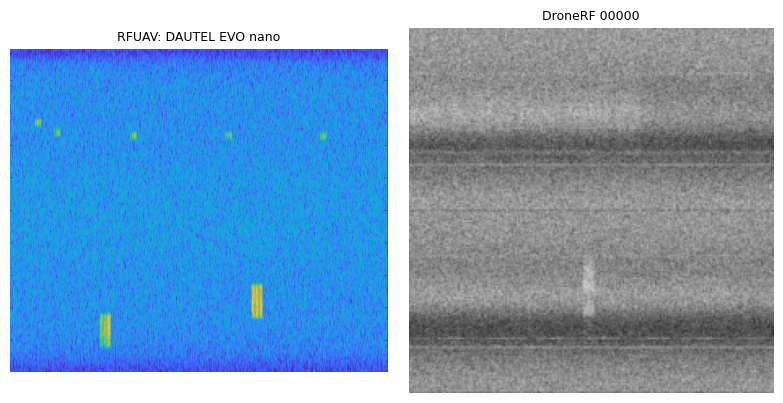

In [2]:
import os, re, glob, numpy as np, pandas as pd
from PIL import Image
from scipy.signal import spectrogram
import matplotlib.pyplot as plt

OUT_DIR = "/kaggle/working/dronerf_spectrograms"
WIN, N_WIN = 500_000, 20            # samples per window, windows per file
NPERSEG, NOVERLAP = 1024, 512
CMAP = None                          # None = grayscale; side-by-side பாத்துட்டு 'viridis' / 'jet' try பண்ணலாம்
os.makedirs(OUT_DIR, exist_ok=True)

pat = re.compile(r'(\d{5})([HL])_(\d+)\.csv$', re.I)
found = {}
for p in glob.glob('/kaggle/input/**/*.csv', recursive=True):
    m = pat.search(os.path.basename(p))
    if m:
        found.setdefault((m.group(1), int(m.group(3))), {})[m.group(2).upper()] = p
pairs = {k: v for k, v in found.items() if 'H' in v and 'L' in v}
print(f"H/L pairs found: {len(pairs)}")
for code in sorted({k[0] for k in pairs}):
    print(f"  code {code}: idx {sorted(i for c, i in pairs if c == code)}")

def load_csv_1d(path):
    try:
        with open(path, 'r') as f:
            arr = np.fromstring(f.read(), dtype=np.float64, sep=',')
    except Exception:
        arr = np.array([])
    if arr.size < 1_000_000:
        arr = pd.read_csv(path, header=None).values.ravel().astype(np.float64)
    return arr

def window_to_img(Lw, Hw):
    _, _, SL = spectrogram(Lw, nperseg=NPERSEG, noverlap=NOVERLAP, mode='magnitude')
    _, _, SH = spectrogram(Hw, nperseg=NPERSEG, noverlap=NOVERLAP, mode='magnitude')
    S = np.flipud(np.vstack([SL, SH]))            # lower half (L) + upper half (H), high freq on top
    S = 20 * np.log10(S + 1e-10)
    lo, hi = np.percentile(S, [5, 99])
    g = np.clip((S - lo) / (hi - lo + 1e-9), 0, 1)
    g = np.array(Image.fromarray((g * 255).astype(np.uint8)).resize((224, 224), Image.BILINEAR)) / 255.0
    if CMAP:
        rgb = (plt.get_cmap(CMAP)(g)[..., :3] * 255).astype(np.uint8)
    else:
        rgb = np.stack([(g * 255).astype(np.uint8)] * 3, axis=-1)
    return Image.fromarray(rgb)

n_saved = 0
for (code, idx), d in sorted(pairs.items()):
    sub = os.path.join(OUT_DIR, code); os.makedirs(sub, exist_ok=True)
    if len(glob.glob(os.path.join(sub, f"{code}_{idx:02d}_w*.png"))) >= N_WIN:
        continue
    Lx, Hx = load_csv_1d(d['L']), load_csv_1d(d['H'])
    n = min(N_WIN, len(Lx) // WIN, len(Hx) // WIN)
    for w in range(n):
        s = slice(w * WIN, (w + 1) * WIN)
        window_to_img(Lx[s], Hx[s]).save(os.path.join(sub, f"{code}_{idx:02d}_w{w:02d}.png"))
        n_saved += 1
    print(f"{code}_{idx}: {n} images")
print("New images saved:", n_saved)

# ---- Visual check: RFUAV vs DroneRF ----
rf_dir = "/kaggle/input/datasets/varshinirajasekaran/rfuav-research/rfuav_images/ImageSet-AllDrones-MatlabPipeline/valid"
rf_cls = sorted(os.listdir(rf_dir))[0]
rf_img = os.path.join(rf_dir, rf_cls, sorted(os.listdir(os.path.join(rf_dir, rf_cls)))[0])
samples = [("RFUAV: " + rf_cls, rf_img)]
for code in sorted(os.listdir(OUT_DIR)):
    fs = sorted(glob.glob(os.path.join(OUT_DIR, code, "*.png")))
    if fs: samples.append((f"DroneRF {code}", fs[0]))
fig, ax = plt.subplots(1, len(samples), figsize=(4 * len(samples), 4))
for a, (t, p) in zip(np.atleast_1d(ax), samples):
    a.imshow(Image.open(p).convert('RGB')); a.set_title(t, fontsize=9); a.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
import os, json, glob, random, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
RESULTS_DIR = "/kaggle/working/results"; os.makedirs(RESULTS_DIR, exist_ok=True)
CKPT_PATH = f"{RESULTS_DIR}/freqmoe_final.pth"
DRONERF_DIR = "/kaggle/working/dronerf_spectrograms"

# ---- RFUAV data ----
base_path = "/kaggle/input/datasets/varshinirajasekaran/rfuav-research/rfuav_images/ImageSet-AllDrones-MatlabPipeline"
unknown_classes = ['DJI MINI4 PRO','SIYI MK32','FRSKY-X20R','FUTABA-T10J','WFLY WFT09SII','FLYSKY EL 18',
                   'YunZhuo-H30','Radiolink AT9S Pro','RadioMaster TX16S','JR PROPO XG7','JUMPER-T14','SKYDROID-H12']
known_classes = [c for c in sorted(os.listdir(f"{base_path}/train")) if c not in unknown_classes]
class_to_idx = {c: i for i, c in enumerate(sorted(known_classes))}

def collect(split, classes):
    P, L = [], []
    for c in sorted(classes):
        d = os.path.join(base_path, split, c)
        if os.path.exists(d):
            for f in sorted(os.listdir(d)):
                if f.lower().endswith('.jpg'): P.append(os.path.join(d, f)); L.append(c)
    return P, L

kv_p, kv_l = collect('valid', known_classes)
ut_p, _ = collect('train', unknown_classes); uv_p, _ = collect('valid', unknown_classes)
rfuav_unk_paths = ut_p + uv_p

eval_tf = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(),
                              transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])])
class ImgDS(Dataset):
    def __init__(self, paths, labels=None, tf=None): self.paths, self.labels, self.tf = paths, labels, tf
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        x = self.tf(Image.open(self.paths[i]).convert('RGB'))
        return x, (class_to_idx[self.labels[i]] if self.labels is not None else -1)
mk = lambda ds: DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)
valid_loader = mk(ImgDS(kv_p, kv_l, eval_tf))
rfuav_unk_loader = mk(ImgDS(rfuav_unk_paths, None, eval_tf))

# ---- Model ----
class FrequencyExpertPretrained(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        bb = models.resnet18(weights='IMAGENET1K_V1'); bb.fc = nn.Identity(); self.backbone = bb
        self.proj = nn.Sequential(nn.Linear(512,256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256,out_dim))
    def forward(self, x): return self.proj(self.backbone(x))
class GatingNetworkV2(nn.Module):
    def __init__(self, in_c=3, n=4):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(in_c,32,3,2,1), nn.BatchNorm2d(32), nn.ReLU(),
                                  nn.Conv2d(32,64,3,2,1), nn.BatchNorm2d(64), nn.ReLU(), nn.AdaptiveAvgPool2d(1))
        self.fc = nn.Sequential(nn.Linear(64,32), nn.ReLU(), nn.Linear(32,n))
    def forward(self, x): x = self.conv(x); return self.fc(x.view(x.size(0), -1))
class FreqMoE_OSR(nn.Module):
    def __init__(self, nc, ne=4, ed=128, sz=224):
        super().__init__()
        self.ne, self.sz, self.bh = ne, sz, sz // ne
        self.experts = nn.ModuleList([FrequencyExpertPretrained(ed) for _ in range(ne)])
        self.gate = GatingNetworkV2(3, ne)
        self.classifier = nn.Sequential(nn.Linear(ed,256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256,nc))
    def forward(self, x):
        eo = []
        for i in range(self.ne):
            s = i * self.bh; e = s + self.bh if i < self.ne - 1 else self.sz
            eo.append(self.experts[i](F.interpolate(x[:, :, s:e, :], size=(self.sz, self.sz), mode='bilinear', align_corners=False)))
        eo = torch.stack(eo, dim=1); gw = F.softmax(self.gate(x), dim=1)
        return self.classifier(torch.sum(eo * gw.unsqueeze(-1), dim=1)), gw

model = FreqMoE_OSR(len(known_classes)).to(device)
if os.path.exists(CKPT_PATH):
    model.load_state_dict(torch.load(CKPT_PATH, map_location=device)); print("Checkpoint loaded")
else:
    print("Checkpoint missing -> training 15 epochs (~25 min)")
    tr_tf = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.RandomHorizontalFlip(0.3),
                                transforms.ToTensor(), transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])])
    tr_p, tr_l = collect('train', known_classes)
    tl = DataLoader(ImgDS(tr_p, tr_l, tr_tf), batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
    opt = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4); crit = nn.CrossEntropyLoss()
    for ep in range(1, 16):
        model.train(); c = t = 0
        for x, y in tl:
            x, y = x.to(device), y.to(device); opt.zero_grad(); lg, _ = model(x)
            crit(lg, y).backward(); opt.step(); c += (lg.argmax(1) == y).sum().item(); t += x.size(0)
        print(f"Epoch {ep}/15 | TrainAcc {c/t:.4f}")
    torch.save(model.state_dict(), CKPT_PATH)
model.eval()

# ---- DroneRF images ----
dr_paths = sorted(glob.glob(os.path.join(DRONERF_DIR, "*", "*.png")))
assert len(dr_paths) > 0, "Cell 1 mudhalla run pannunga - dronerf_spectrograms-la PNG illa"
dr_group = np.array([os.path.basename(os.path.dirname(p)) for p in dr_paths])
dr_cluster = np.array([os.path.basename(p).rsplit('_w', 1)[0] for p in dr_paths])
dr_loader = mk(ImgDS(dr_paths, None, eval_tf))
print("DroneRF images:", len(dr_paths), "| groups:", {g: int((dr_group == g).sum()) for g in np.unique(dr_group)})

# ---- Scores ----
@torch.no_grad()
def get_out(loader):
    C, P, Y = [], [], []
    for x, y in loader:
        lg, _ = model(x.to(device)); pr = F.softmax(lg, 1)
        C.extend(pr.max(1)[0].cpu().numpy()); P.extend(pr.argmax(1).cpu().numpy()); Y.extend(y.numpy())
    return np.array(C), np.array(P), np.array(Y)

known_conf, kp, ky = get_out(valid_loader)
rfuav_unk_conf, _, _ = get_out(rfuav_unk_loader)
dr_conf, _, _ = get_out(dr_loader)
acc, mf1 = accuracy_score(ky, kp), f1_score(ky, kp, average='macro', zero_division=0)

auroc = lambda k, u: roc_auc_score(np.r_[np.ones(len(k)), np.zeros(len(u))], np.r_[k, u])
def cluster_boot(k, u, cl, n=1000, seed=42):
    rng = np.random.RandomState(seed); ucl = np.unique(cl); by = {c: u[cl == c] for c in ucl}; v = []
    for _ in range(n):
        us = np.concatenate([by[c] for c in rng.choice(ucl, len(ucl))])
        v.append(auroc(rng.choice(k, len(k)), us))
    return [float(np.mean(v)), float(np.std(v)), float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))]

tau = float(np.percentile(known_conf, 5))
res = {'closed_set_accuracy': float(acc), 'closed_set_macro_f1': float(mf1), 'threshold': tau,
       'rfuav_unknown': {'auroc': float(auroc(known_conf, rfuav_unk_conf)),
                         'rejection_rate': float(np.mean(rfuav_unk_conf < tau)), 'n': int(len(rfuav_unk_conf))},
       'dronerf_groups': {}}

def summarize(name, mask):
    u, cl = dr_conf[mask], dr_cluster[mask]
    return {'n_images': int(mask.sum()), 'n_segments': int(len(np.unique(cl))), 'mean_conf': float(u.mean()),
            'auroc': float(auroc(known_conf, u)), 'rejection_rate': float(np.mean(u < tau)),
            'cluster_bootstrap_[mean,std,ci_lo,ci_hi]': cluster_boot(known_conf, u, cl)}

for g in np.unique(dr_group):
    res['dronerf_groups'][g] = summarize(g, dr_group == g)
drone_mask = np.array([g[0] == '1' for g in dr_group])   # first digit 1 = drone present (verify in DroneRF docs)
if drone_mask.any():   res['dronerf_all_drone_pooled'] = summarize('drone', drone_mask)
if (~drone_mask).any(): res['dronerf_background_pooled'] = summarize('bg', ~drone_mask)

print("\n" + "=" * 70)
print(f"Closed-set acc {acc:.4f} | macro-F1 {mf1:.4f} | known mean conf {known_conf.mean():.4f} | tau {tau:.4f}")
print(f"RFUAV unknown: AUROC {res['rfuav_unknown']['auroc']:.4f} | rejection {res['rfuav_unknown']['rejection_rate']:.4f}")
for k, v in {**res['dronerf_groups'], **{k: res[k] for k in ['dronerf_all_drone_pooled', 'dronerf_background_pooled'] if k in res}}.items():
    b = v['cluster_bootstrap_[mean,std,ci_lo,ci_hi]']
    print(f"DroneRF {k:>26}: n={v['n_images']:>5} seg={v['n_segments']:>3} | meanConf {v['mean_conf']:.3f} | "
          f"AUROC {v['auroc']:.4f} (95% CI {b[2]:.3f}-{b[3]:.3f}) | rej {v['rejection_rate']:.3f}")
print("=" * 70)
with open(f"{RESULTS_DIR}/cross_dataset_dronerf_raw.json", "w") as f: json.dump(res, f, indent=4)
print("Saved:", f"{RESULTS_DIR}/cross_dataset_dronerf_raw.json")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s] 


Checkpoint missing -> training 15 epochs (~25 min)
Epoch 1/15 | TrainAcc 0.5561
Epoch 2/15 | TrainAcc 0.8749
Epoch 3/15 | TrainAcc 0.9651
Epoch 4/15 | TrainAcc 0.9783
